In [113]:
import pickle
import osmnx as ox
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from tqdm.auto import tqdm
from shapely.geometry import Point, MultiPolygon, Polygon
from copy import deepcopy

import matplotlib.pyplot as plt
import seaborn as sns
import h3


In [2]:
def load_gdfs(root: str | Path, pattern: str = "*.pkl", target_crs: str | None = None) -> list[gpd.GeoDataFrame]:
    """
    Загружает GeoDataFrame'ы из .pkl файлов:
      - если root указывает на один .pkl файл — читаем его и возвращаем список [GDF]
      - если root — папка — рекурсивно ищем по маске pattern и возвращаем список GDF

    Пытаемся заполнить столбцы 'city' и 'country' из структуры путей:
    .../<country>/<city>/<file>.pkl

    Args:
        root: путь к файлу .pkl или папке
        pattern: маска файлов (по умолчанию "*.pkl") — используется только если root папка
        target_crs: если указан, приводим все геоданные к этому CRS

    Returns:
        list[GeoDataFrame]
    """
    p = Path(root)

    def _ensure_gdf(obj):
        """Преобразует объект в GeoDataFrame, если это DataFrame с колонкой 'geometry'."""
        if isinstance(obj, gpd.GeoDataFrame):
            return obj
        if isinstance(obj, pd.DataFrame) and "geometry" in obj.columns:
            return gpd.GeoDataFrame(obj, geometry="geometry", crs=getattr(obj, "crs", None))
        return None

    def _infer_city_country(fp: Path):
        # ожидаем .../<country>/<city>/<file>.pkl
        city = fp.name[:-4] if fp else None
        country = fp.parent.name if len(fp.parents) >= 2 else None
        return city, country

    # Соберём список файлов
    if p.is_file() and p.suffix.lower() == ".pkl":
        files = [p]
    elif p.is_dir():
        files = sorted(p.rglob(pattern))
        files = [f for f in files if f.suffix.lower() == ".pkl"]
    else:
        return []

    gdfs: list[gpd.GeoDataFrame] = []

    for fp in files:
        try:
            with open(fp, "rb") as f:
                obj = pickle.load(f)
        except Exception as e:
            print(f"Пропускаю {fp}: {e}")
            continue

        # Если GeoDataFrame
        gdf = _ensure_gdf(obj)

        # Если dict с GeoDataFrame
        if gdf is None and isinstance(obj, dict):
            for k, v in obj.items():
                gi = _ensure_gdf(v)
                if gi is None:
                    continue
                gi = gi.copy()
                if "city" not in gi.columns or gi["city"].isna().all():
                    gi["city"] = str(k)
                _, country = _infer_city_country(fp)
                if ("country" not in gi.columns) and country:
                    gi["country"] = country
                if target_crs:
                    gi = gi.to_crs(target_crs) if gi.crs else gi.set_crs(target_crs)
                gdfs.append(gi)
            continue

        if gdf is None:
            print(f"Пропускаю {fp}: объект не GeoDataFrame и не dict с GeoDataFrame.")
            continue

        gdf = gdf.copy()
        city, country = _infer_city_country(fp)
        if "city" not in gdf.columns:
            gdf["city"] = city or fp.stem
        if ("country" not in gdf.columns) and country:
            gdf["country"] = country

        if target_crs:
            gdf = gdf.to_crs(target_crs) if gdf.crs else gdf.set_crs(target_crs)

        gdfs.append(gdf)

    return gdfs

blocks_gdf = load_gdfs('data/TANYA-2025 v2/Russia')
spb_test = gpd.read_file('data/blocks_SPB_test.gpkg')[['land_use', 'geometry']]
kem_test = gpd.read_file('data/blocks_KEM_test.gpkg')[['land_use', 'geometry']]

kem_test.loc[kem_test['land_use'] == 'businnes', 'land_use'] = 'business'

In [ ]:
def get_city_boundary(city_name, country_name):
    """
    Возвращает GeoDataFrame с границей города.
    Пытается найти именно город (place=city), а не административный район.
    """
    query = f"city {city_name}, {country_name}"
    
    # --- 1. Попробуем найти как "place=city" ---
    try:
        gdf_city = ox.geocode_to_gdf(
            query,
            which_result=1,           # первый результат
            structure='polygon',      # только полигоны
            tags={'place': 'city'}    # фильтр по типу
        )
        if not gdf_city.empty:
            print(f"✅ Найден город как place=city: {city_name}")
            return gdf_city
    except Exception as e:
        pass  # пробуем следующий вариант
    
    # --- 2. Попробуем admin_level=8 (городской уровень) ---
    try:
        gdf_city = ox.geocode_to_gdf(
            query,
            which_result=1,
            structure='polygon',
            tags={'admin_level': '8'}
        )
        if not gdf_city.empty:
            print(f"✅ Найден город как admin_level=8: {city_name}")
            return gdf_city
    except Exception as e:
        pass
    
    # --- 3. Если ничего не нашли — попробуем просто первую границу ---
    try:
        gdf_city = ox.geocode_to_gdf(query, which_result=1)
        if not gdf_city.empty:
            print(f"⚠️ Используем первую найденную границу (возможно, район): {city_name}")
            return gdf_city
    except Exception as e:
        print(f"❌ Не удалось найти границу для: {query}")
        pass
    
    try:
        query = f"{city_name}, {country_name}"
        gdf_city = ox.geocode_to_gdf(query, which_result=1)
        if not gdf_city.empty:
            print(f"⚠️ Используем первую найденную границу (возможно, район): {city_name}")
            return gdf_city
    except Exception as e:
        print(f"❌ Не удалось найти границу для: {query}")
        return None

# --- Обработка каждого города ---
city_gdfs_with_coverage = []

for index, gdf in enumerate(blocks_gdf):
    gdf = gdf.copy()
    
    # Получаем имя города и страны из первой строки (предполагаем, что весь gdf — один город)
    city_name = gdf['city'].iloc[0]
    country_name = gdf['country'].iloc[0]
    
    # Определяем UTM CRS
    utm_crs = gdf.estimate_utm_crs()
    gdf.to_crs(utm_crs, inplace=True)
    
    # --- Шаг 1: Получаем границу города ---
    city_boundary = get_city_boundary(city_name, country_name)
    
    if city_boundary is None:
        print(f"❌ Пропуск города {city_name}, {country_name} — не найдена граница")
        # Добавляем пустые колонки
        gdf['area_pct_of_city'] = np.nan
        gdf['city_boundary_area_m2'] = np.nan
        gdf['covered_area_ratio'] = np.nan
        city_gdfs_with_coverage.append(gdf)
        continue
    
    # Переводим границу в UTM, если нужно
    if city_boundary.crs != utm_crs:
        city_boundary.to_crs(utm_crs, inplace=True)
    
    # --- Шаг 2: Площадь города ---
    total_city_area = city_boundary.area.values  # в м²
    
    # --- Шаг 3: Площадь каждого квартала ---
    gdf['area_m2'] = gdf.geometry.area
    
    # Доля квартала от общей площади города (%)
    gdf['area_pct_of_city'] = (gdf['area_m2'] / total_city_area) * 100
    
    # --- Шаг 4: Доля непокрытой территории ---
    total_blocks_area = gdf['area_m2'].sum()
    uncovered_ratio = max(0.0, (total_city_area[0] - total_blocks_area) / total_city_area[0])
    
    # Добавляем как колонку (одинаковое значение для всех строк города)
    gdf['city_boundary_area_m2'] = total_city_area[0]
    gdf['covered_area_ratio'] = 1 - uncovered_ratio
    
    # Сохраняем геометрию границы (опционально)
    gdf['city_boundary_geometry'] = city_boundary['geometry'].iloc[0]
    
    # --- Лог ---
    # print(f"{index:>3}. 🏙️ {city_name}, {country_name}")
    # print(f"   Площадь города: {total_city_area[0]:,.0f} м²")
    # print(f"   Сумма кварталов: {total_blocks_area:,.0f} м²")
    # print(f"   Покрытие: {100*(1 - uncovered_ratio):.1f}% | Не размечено: {100*uncovered_ratio:.1f}%")
    # print("-" * 50)
    
    city_gdfs_with_coverage.append(gdf)

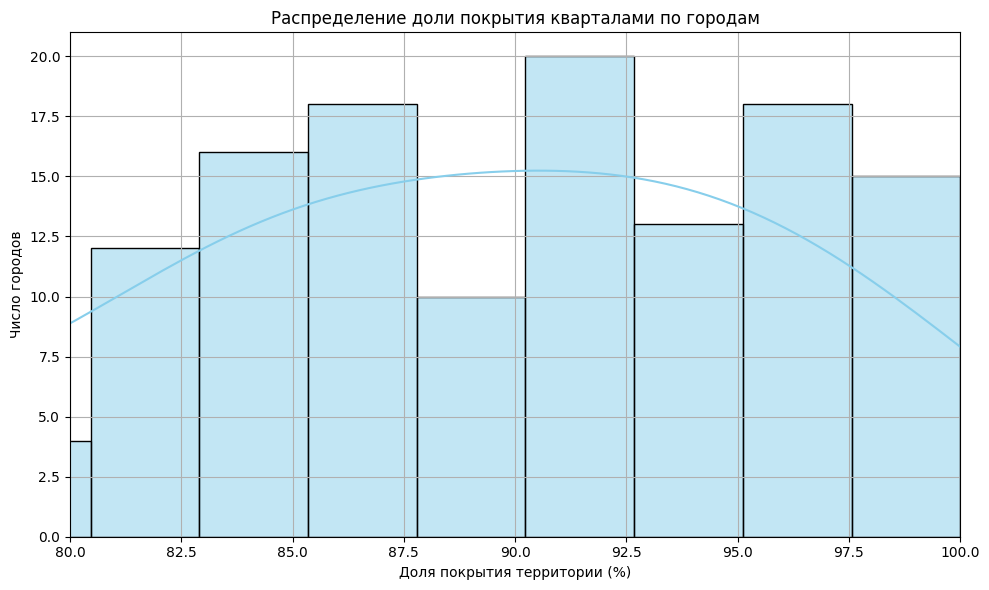

In [4]:
# Собираем метаданные по городам
city_metadata = []

for gdf in city_gdfs_with_coverage:
    city = gdf['city'].iloc[0]
    country = gdf['country'].iloc[0]
    covered_ratio = gdf['covered_area_ratio'].iloc[0]
    total_city_area = gdf['city_boundary_area_m2'].iloc[0]
    total_block_area = gdf['area_m2'].sum()
    
    city_metadata.append({
        'city': city,
        'country': country,
        'covered_ratio': covered_ratio,  # доля покрытия
        'total_city_area_km2': total_city_area / 1e6,  # м² → км²
        'total_block_area_km2': total_block_area / 1e6
    })

# Преобразуем в DataFrame
city_coverage_df = pd.DataFrame(city_metadata)

# Гистограмма доли покрытия
plt.figure(figsize=(10, 6))
sns.histplot(city_coverage_df['covered_ratio'] * 100, bins=20, kde=True, color='skyblue')
plt.title('Распределение доли покрытия кварталами по городам')
plt.xlim(left=80, right=100)
plt.ylim(bottom=0)
plt.xlabel('Доля покрытия территории (%)')
plt.ylabel('Число городов')
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
# Собираем результаты
city_landuse_coverage = []

for gdf in city_gdfs_with_coverage:
    gdf['land_use_name'] = gdf['land_use'].apply(lambda x: x.value)
    # Группируем по land_use и суммируем area_pct_of_city
    coverage_by_type = (
        gdf.groupby('land_use_name')['area_pct_of_city']
        .sum()
        .reset_index()
        .rename(columns={'area_pct_of_city': 'coverage_pct'})
    )
    
    # Добавляем информацию о городе
    city_name = gdf['city'].iloc[0]
    country_name = gdf['country'].iloc[0]
    total_covered_ratio = gdf['covered_area_ratio'].iloc[0]  # доля покрытия (1 - uncovered)
    
    coverage_by_type['city'] = city_name
    coverage_by_type['country'] = country_name
    coverage_by_type['total_covered_pct'] = total_covered_ratio * 100  # в процентах
    
    city_landuse_coverage.append(coverage_by_type)

# Объединяем всё в один DataFrame
all_coverage_df = pd.concat(city_landuse_coverage, ignore_index=True)

# Переводим в удобный формат
all_coverage_df = all_coverage_df[['city', 'country', 'land_use_name', 'coverage_pct', 'total_covered_pct']]
all_coverage_df = all_coverage_df.round(3)

print("✅ Готово! Покрытие по типам землепользования для всех городов:")
all_coverage_df.head(10)

✅ Готово! Покрытие по типам землепользования для всех городов:


,city,country,land_use_name,coverage_pct,total_covered_pct
0,Abakan,Russia,agriculture,32.721,86.617
1,Abakan,Russia,business,0.999,86.617
2,Abakan,Russia,industrial,12.821,86.617
3,Abakan,Russia,recreation,1.882,86.617
4,Abakan,Russia,residential,32.211,86.617
5,Abakan,Russia,special,2.335,86.617
6,Abakan,Russia,transport,3.649,86.617
7,Achinsk,Russia,agriculture,19.296,69.298
8,Achinsk,Russia,business,0.184,69.298
9,Achinsk,Russia,industrial,11.686,69.298


In [6]:
# Шаг 1: Найдём все города, где residential > 60%
cities_to_remove = all_coverage_df[
    (all_coverage_df['land_use_name'].str.upper() == 'RESIDENTIAL') & (all_coverage_df['coverage_pct'] > 50) |
    (all_coverage_df['land_use_name'].str.upper() == 'RESIDENTIAL') & (all_coverage_df['coverage_pct'] < 10) |
    (all_coverage_df['land_use_name'].str.upper() == 'AGRICULTURE') & (all_coverage_df['coverage_pct'] > 40) |
    (all_coverage_df['total_covered_pct'] < 80) 
]['city']

# Преобразуем в множество для быстрого поиска
cities_to_remove_set = set(cities_to_remove)

print(f"❌ Города с RESIDENTIAL > 60%, RESIDENTIAL < 10%, AGRICULTURE > 40% (будут удалены): {len(cities_to_remove_set)} шт.")

❌ Города с RESIDENTIAL > 60%, RESIDENTIAL < 10%, AGRICULTURE > 40% (будут удалены): 78 шт.


In [7]:
# Удаляем ВСЕ строки, где city в списке cities_to_remove_set
all_coverage_df_filter = all_coverage_df[
    ~all_coverage_df['city'].isin(cities_to_remove_set)
].copy()

print(f"✅ Осталось городов: {all_coverage_df_filter['city'].nunique()}")

UNIQUE_CITIES = all_coverage_df_filter['city'].unique()

✅ Осталось городов: 82


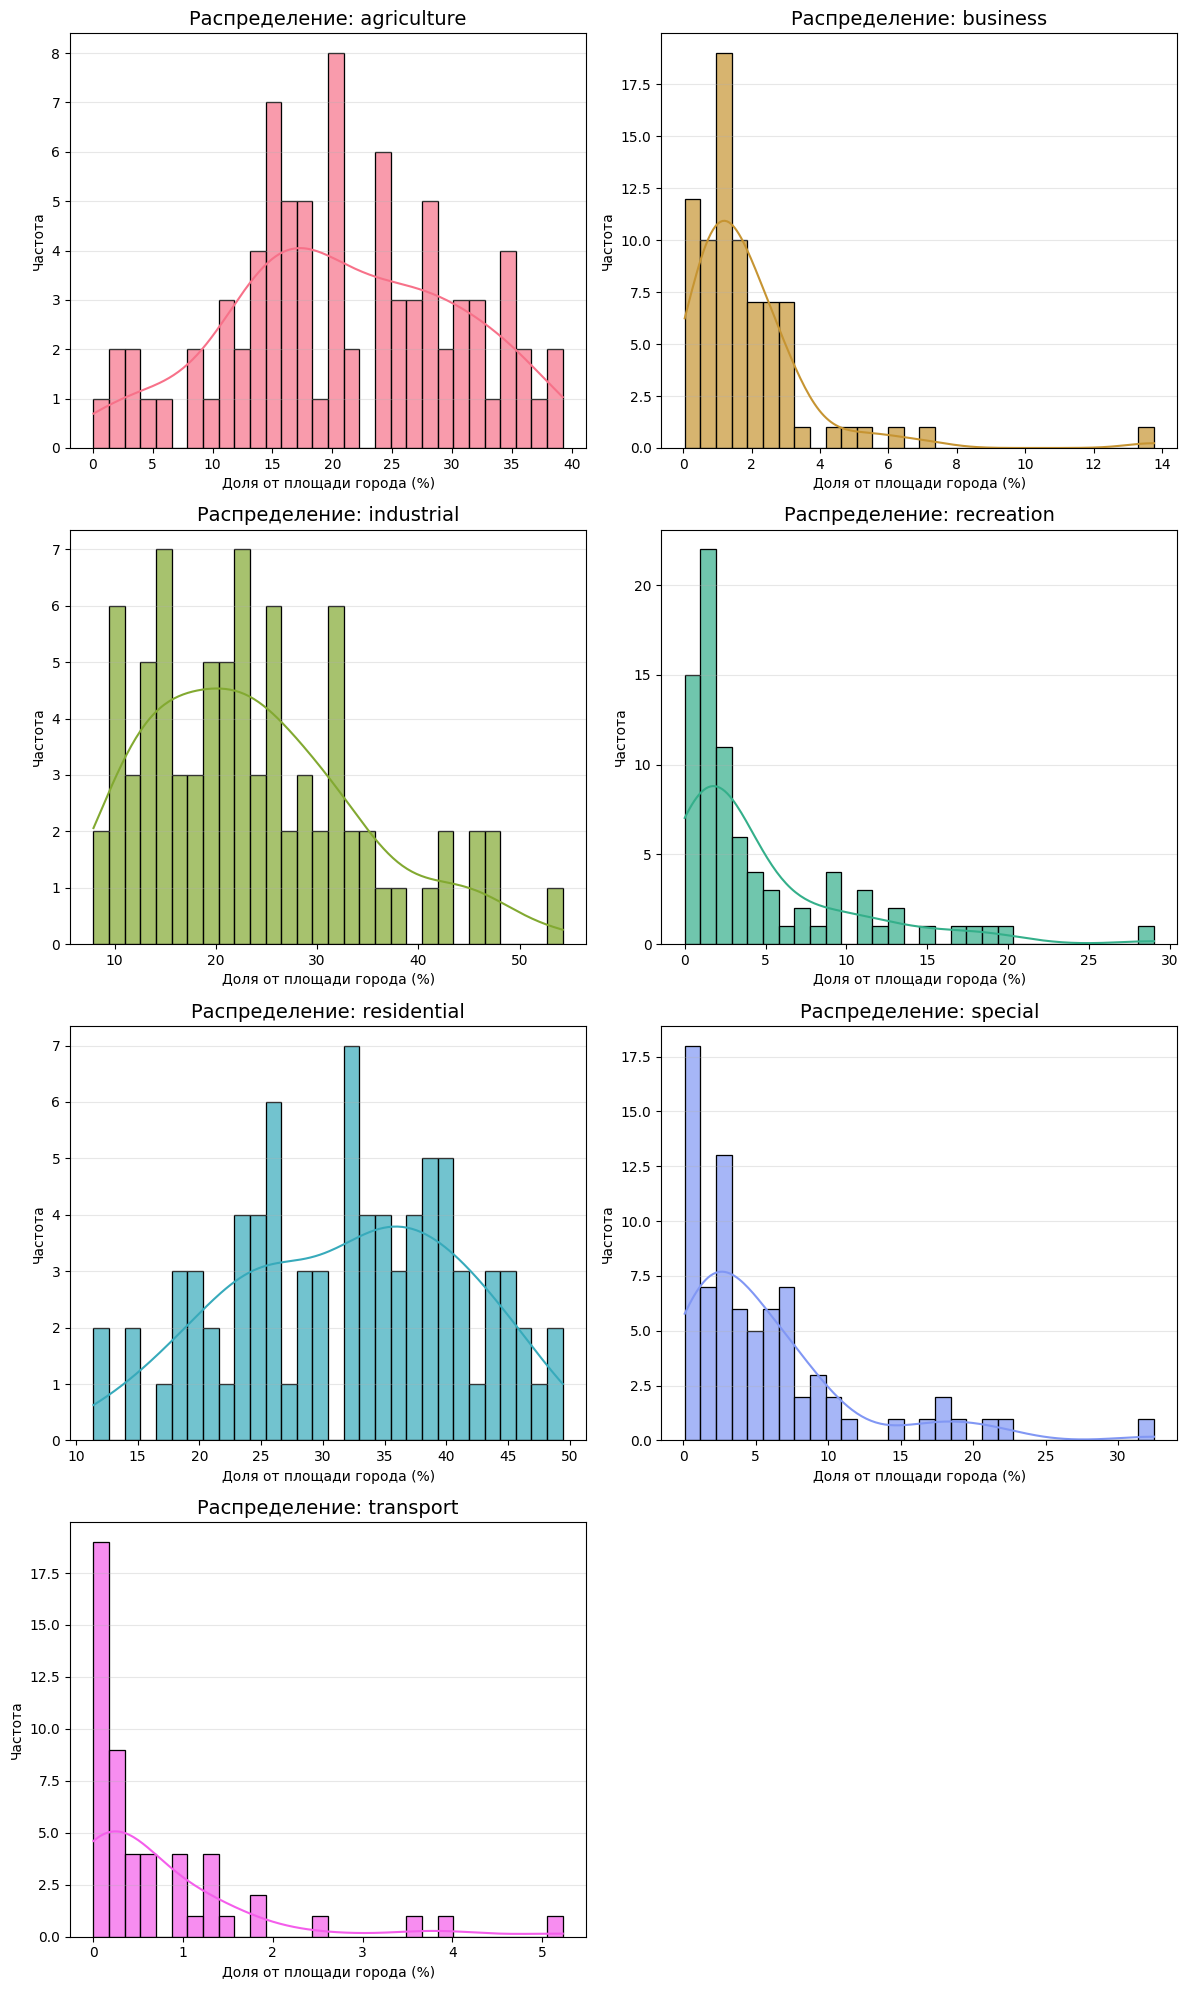

In [8]:
# Получаем список уникальных типов землепользования
land_use_types = all_coverage_df_filter['land_use_name'].unique()
n_types = len(land_use_types)

# Настройка сетки графиков
cols = 2
rows = (n_types + cols - 1) // cols  # округление вверх
fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
axes = axes.flatten() if n_types > 1 else [axes]

# Цвета — можно использовать палитру
colors = sns.color_palette("husl", n_types)

for idx, land_use in enumerate(land_use_types):
    ax = axes[idx]
    data = all_coverage_df_filter[all_coverage_df_filter['land_use_name'] == land_use]['coverage_pct'].dropna()
    
    if len(data) == 0:
        ax.text(0.5, 0.5, 'Нет данных', transform=ax.transAxes, ha='center', va='center')
        ax.set_title(f"{land_use} (пусто)")
    else:
        # Гистограмма + KDE
        sns.histplot(data, bins=30, kde=True, ax=ax, color=colors[idx], alpha=0.7)
        ax.set_title(f"Распределение: {land_use}", fontsize=14)
        ax.set_xlabel('Доля от площади города (%)')
        ax.set_ylabel('Частота')
        ax.grid(True, axis='y', alpha=0.3)

# Скрыть лишние подграфики
for idx in range(n_types, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
# Маппинг 7 → 2
mapping_7_to_2 = {
    "INDUSTRIAL": "NOT_LIVING",
    "RECREATION": "NOT_LIVING",
    "BUSINESS": "NOT_LIVING",
    "RESIDENTIAL": "LIVING",
    "AGRICULTURE": "NOT_LIVING",
    "SPECIAL": "NOT_LIVING",
    "TRANSPORT": "NOT_LIVING"
}

mapping_7_to_3 = {
    "INDUSTRIAL": "LARGEAREA",
    "RECREATION": "LARGEAREA",
    "BUSINESS": "MIXEDUSE",
    "RESIDENTIAL": "MIXEDUSE",
    "AGRICULTURE": "LARGEAREA",
    "SPECIAL": "ENGINEERING",
    "TRANSPORT": "ENGINEERING"
}

mapping_7_to_4 = {
    "INDUSTRIAL": "INDUSTRIAL",
    "RECREATION": "RECREATION",
    "BUSINESS": "MIXEDUSE",
    "RESIDENTIAL": "MIXEDUSE",
    "AGRICULTURE": "RECREATION",
    "SPECIAL": "ENGINEERING",
    "TRANSPORT": "ENGINEERING"
}

mapping_7_to_7 = {
    "INDUSTRIAL": "INDUSTRIAL",
    "RECREATION": "RECREATION",
    "BUSINESS": "BUSINESS",
    "RESIDENTIAL": "RESIDENTIAL",
    "AGRICULTURE": "AGRICULTURE",
    "SPECIAL": "SPECIAL",
    "TRANSPORT": "TRANSPORT"
}

# Создаём новый список GeoDataFrame'ов с бинарными метками
city_gdfs_binary = []

for gdf_city in blocks_gdf:  # ваш list(gdf) по городам
    # Глубокая копия, чтобы не изменять оригинал
    gdf_bin = deepcopy(gdf_city)
    
    # Предполагаем, что категория хранится в колонке 'CATEGORY' как строка
    # Если это Enum — конвертируем в строку
    if gdf_bin['land_use'].dtype == 'object':
        cat_str = gdf_bin['land_use'].astype(str).str.split('.').str[-1]  # если Enum: 'land_use.RESIDENTIAL' → 'RESIDENTIAL'
    else:
        cat_str = gdf_bin['land_use'].apply(lambda x: x.value if hasattr(x, 'value') else x)
    
    # Маппинг в бинарный класс
    gdf_bin['target'] = cat_str.map(mapping_7_to_7)
    
    # Опционально: сохраняем оригинальную категорию
    # gdf_bin['land_use_ORIGINAL'] = cat_str
    
    city_gdfs_binary.append(gdf_bin)

spb_test['target'] = spb_test['land_use'].str.upper().map(mapping_7_to_7)
kem_test['target'] = kem_test['land_use'].str.upper().map(mapping_7_to_7)

spb_test.dropna(inplace=True)
kem_test.dropna(inplace=True)

spb_test.reset_index(drop=True, inplace=True)
kem_test.reset_index(drop=True, inplace=True)

In [10]:
def mask_random_targets(
    gdf,
    target_col="target",
    min_frac=0.1,
    max_frac=0.7,
    random_state=None
):
    """
    Случайно заменяет от min_frac до max_frac значений target_col на None.
    Для каждого GeoDataFrame доля выбирается случайно.
    """
    gdf = gdf.copy()
    rng = np.random.default_rng(random_state)
    frac = rng.uniform(min_frac, max_frac)
    mask = rng.random(len(gdf)) < frac
    gdf.loc[mask, target_col] = None
    gdf.attrs["masked_frac"] = frac
    return gdf

# --- применяем к списку городов ---
city_gdfs_binary_mask = [
    mask_random_targets(gdf, target_col="target", random_state=i)
    for i, gdf in enumerate(tqdm(city_gdfs_binary, desc="Masking targets"))
]

spb_test_mask = mask_random_targets(spb_test, target_col="target", random_state=42)
kem_test_mask = mask_random_targets(kem_test, target_col="target", random_state=42)

# можно вывести сводку
for i, gdf in enumerate(city_gdfs_binary_mask[:10]):
    frac = gdf.attrs.get("masked_frac", None)
    if frac is not None:
        print(f"Город {i+1:>3}: скрыто {frac*100:.1f}% меток (≈ {gdf['target'].isna().sum():>3} из {len(gdf):>4})")

print(f"Город СПб: скрыто {spb_test_mask.attrs.get('masked_frac', None)*100:.1f}% меток (≈ {spb_test_mask['target'].isna().sum():>3} из {len(spb_test_mask):>4})")
print(f"Город Кемерово: скрыто {kem_test_mask.attrs.get('masked_frac', None)*100:.1f}% меток (≈ {kem_test_mask['target'].isna().sum():>3} из {len(kem_test_mask):>4})")

Masking targets:   0%|          | 0/160 [00:00<?, ?it/s]

Город   1: скрыто 48.2% меток (≈ 455 из 1002)
Город   2: скрыто 40.7% меток (≈ 165 из  385)
Город   3: скрыто 25.7% меток (≈ 168 из  614)
Город   4: скрыто 15.1% меток (≈ 131 из  806)
Город   5: скрыто 66.6% меток (≈ 172 из  289)
Город   6: скрыто 58.3% меток (≈ 230 из  372)
Город   7: скрыто 42.3% меток (≈ 141 из  340)
Город   8: скрыто 47.5% меток (≈ 788 из 1615)
Город   9: скрыто 29.6% меток (≈  85 из  278)
Город  10: скрыто 62.2% меток (≈ 496 из  796)
Город СПб: скрыто 56.4% меток (≈ 5268 из 9249)
Город Кемерово: скрыто 56.4% меток (≈ 1082 из 1918)


In [121]:
import networkx as nx
from tqdm.notebook import tqdm
from scipy.spatial.distance import cdist


def _mrr_metrics(geom):
    """
    Метрики минимального повёрнутого прямоугольника (MRR) для полигона:
    ширина, высота, площадь и аспект (width/height, >=1).
    Возвращает (width, height, area, aspect_ratio).
    """
    try:
        mrr = geom.minimum_rotated_rectangle
        coords = np.array(mrr.exterior.coords)
        # четыре уникальные длины сторон
        edges = np.sqrt(((coords[1:] - coords[:-1])**2).sum(axis=1))
        # в MRR есть две пары равных сторон; берём две уникальные длины
        lengths = np.sort(np.unique(np.round(edges, 12)))
        if len(lengths) >= 2:
            width, height = float(lengths[-1]), float(lengths[-2])
        elif len(lengths) == 1:
            width, height = float(lengths[0]), float(lengths[0])
        else:
            width = height = 0.0
        area = float(mrr.area)
        w, h = (width, height) if width >= height else (height, width)
        aspect = (w / (h + 1e-12)) if (w > 0 and h > 0) else 1.0
        return w, h, area, aspect
    except Exception:
        return 0.0, 0.0, 0.0, 1.0

def add_spatial_features(
    gdf: gpd.GeoDataFrame,
    target_col: str = "target",
    rings=((0, 150), (150, 500), (500, 1000)),
    batch_size: int = 500,
    h3_resolution: int = 9,
) -> gpd.GeoDataFrame:
    """
    Признаки для классификации типа землепользования:
      • геометрия формы (в т.ч. фрактальность/прямоугольность/ориентация MRR),
      • пространственные признаки соседства в радиусах (100, 500, 1000 м),
      • локальные метрические признаки (межквартальные расстояния),
      • графовые признаки по соседству через буфер 10 м (networkx).
    """
    gdf = gdf.copy()
    utm_crs = gdf.estimate_utm_crs()
    gdf = gdf.to_crs(utm_crs)

    # --- Геометрические признаки ---
    gdf["area"] = gdf.geometry.area
    gdf["perimeter"] = gdf.geometry.length
    # компактность (округлость)
    gdf["compactness"] = (4 * np.pi * gdf["area"]) / (gdf["perimeter"]**2 + 1e-12)
    # выпуклая оболочка и «заполненность»
    gdf["convex_hull_area"] = gdf.geometry.convex_hull.area
    gdf["solidity"] = gdf["area"] / (gdf["convex_hull_area"] + 1e-12)

    # ограничивающий bbox
    bounds = gdf.geometry.bounds
    gdf["bbox_width"]  = bounds["maxx"] - bounds["minx"]
    gdf["bbox_height"] = bounds["maxy"] - bounds["miny"]
    gdf["elongation"] = np.where(
        gdf["bbox_height"] > 0,
        gdf["bbox_width"] / (gdf["bbox_height"] + 1e-12),
        1.0
    )

    # --- Форма по минимальному повёрнутому прямоугольнику (MRR) ---
    mrr_vals = gdf.geometry.apply(_mrr_metrics)
    # gdf["mrr_width"]        = [t[0] for t in mrr_vals]
    gdf["mrr_height"]       = [t[1] for t in mrr_vals]
    gdf["mrr_area"]         = [t[2] for t in mrr_vals]
    gdf["mrr_aspect_ratio"] = [t[3] for t in mrr_vals]
    # прямоугольность: насколько форма заполняет MRR
    gdf["rectangularity_index"] = gdf["area"] / (gdf["mrr_area"] + 1e-12)
    # индекс сложности формы (Miller): чем выше, тем граница «извилистее»
    gdf["shape_index"] = 0.25 * gdf["perimeter"] / np.sqrt(gdf["area"] + 1e-12)
    # приближённая фрактальная размерность границы (масштабно-инвариантная эвристика)
    # FD ~ 2 * log(P/4) / log(A)
    gdf["fractal_dimension"] = (
        2.0 * np.log((gdf["perimeter"] + 1e-12) / 4.0) / np.log(gdf["area"] + 1e-12)
    ).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0, upper=2.5)

    # --- Пространственные признаки для нескольких колец (r_min, r_max) ---
    for r_min, r_max in rings:
        buf_max = gdf.geometry.buffer(r_max)
        if r_min and r_min > 0:
            buf_min = gdf.geometry.buffer(r_min)
            ring_geom = buf_max.difference(buf_min)
        else:
            ring_geom = buf_max

        right = gpd.GeoDataFrame(
            gdf[[target_col, "area"]].copy(),
            geometry=ring_geom,
            crs=gdf.crs
        )

        joined = gpd.sjoin(
            gdf[[target_col, "geometry", "area"]],
            right,
            how="left",
            predicate="intersects",
            lsuffix="A",
            rsuffix="B",
        ).reset_index()

        left_index = "index"
        right_index = "index_B"
        if left_index not in joined.columns and joined.index.name:
            joined = joined.reset_index(names="index_left")
            left_index = "index_left"

        joined = joined[joined[left_index] != joined[right_index]]

        # --- обработка пропусков ---
        joined[f"{target_col}_B"] = joined[f"{target_col}_B"].fillna("__none__")

        # базовые агрегаты
        n_neighbors = joined.groupby(left_index).size()
        avg_area_neighbors = joined.groupby(left_index)["area_B"].mean()

        # количество и площадь соседей без категории
        none_mask = joined[f"{target_col}_B"] == "__none__"
        n_neighbors_none = none_mask.groupby(joined[left_index]).sum()
        avg_area_none = (
            joined.loc[none_mask].groupby(left_index)["area_B"].mean()
            if none_mask.any()
            else pd.Series(dtype=float)
        )
        band = f"{int(r_min)}_{int(r_max)}m"
        gdf[f"n_neighbors_{band}m"] = gdf.index.map(n_neighbors).fillna(0).astype(int)
        gdf[f"avg_area_neighbors_{band}m"] = gdf.index.map(avg_area_neighbors).fillna(0.0)
        gdf[f"n_neighbors_none_{band}m"] = gdf.index.map(n_neighbors_none).fillna(0).astype(int)
        gdf[f"avg_area_neighbors_none_{band}m"] = gdf.index.map(avg_area_none).fillna(0.0)

        # --- распределение по классам (без None) ---
        pct_by_class = (
            joined[joined[f"{target_col}_B"] != "__none__"]
            .groupby([left_index, f"{target_col}_B"])
            .size()
            .unstack(fill_value=0)
        )
        pct_by_class = pct_by_class.div(pct_by_class.sum(axis=1), axis=0)

        for cls in pct_by_class.columns:
            gdf[f"pct_neighbor_{str(cls).lower()}_{band}m"] = (
                gdf.index.map(pct_by_class[cls]).fillna(0.0)
            )

    # --- Локальные метрические признаки (cdist, representative_point) ---
    reps = gdf.geometry.representative_point()
    coords = np.column_stack((reps.x.values, reps.y.values)).astype(float)
    n = len(coords)

    # создаём заготовки под метрики
    median_dist = np.zeros(n)
    mean_k3_dist = np.zeros(n)

    if n > 1:
        for i in range(0, n, batch_size):
            batch = coords[i:i + batch_size]
            dist_block = cdist(batch, coords)
            # маскируем «самого себя»
            row_idx, col_idx = np.indices(dist_block.shape)
            self_mask = (row_idx + i == col_idx)
            dist_block[self_mask] = np.nan

            # медианное расстояние до всех остальных
            median_dist[i:i + batch_size] = np.nanmedian(dist_block, axis=1)

            # сортируем и берём разные k
            sorted_dist = np.sort(dist_block, axis=1)
            k_lim = min(3, sorted_dist.shape[1] - 1)
            mean_k3_dist[i:i + batch_size] = np.nanmean(sorted_dist[:, :k_lim], axis=1)

    # добавляем в GeoDataFrame
    gdf["median_dist"] = median_dist
    gdf["mean_k3_dist"] = mean_k3_dist

    # --- Граф по пересечениям с буфером 10 м (networkx) ---
    # левая — исходная геометрия, правая — буфер 10 м
    buf10 = gdf.geometry.buffer(10.0)
    right10 = gpd.GeoDataFrame(
        index=gdf.index,
        geometry=buf10,
        crs=gdf.crs
    )
    pairs = gpd.sjoin(
        gdf[["geometry"]], right10,
        how="left", predicate="intersects",
        lsuffix="L", rsuffix="R"
    ).reset_index()

    li = "index"
    ri = "index_R"
    if li not in pairs.columns and pairs.index.name:
        pairs = pairs.reset_index(names="index_left")
        li = "index_left"

    # удаляем самосоединения
    pairs = pairs[pairs[li] != pairs[ri]]
    # формируем уникальные неориентированные рёбра
    edges = {(int(a), int(b)) if a < b else (int(b), int(a))
             for a, b in zip(pairs[li], pairs[ri])}
    G = nx.Graph()
    G.add_nodes_from(gdf.index.astype(int).tolist())
    G.add_edges_from(edges)

    # степень
    deg = dict(G.degree())
    gdf["deg_10m"] = gdf.index.map(deg).fillna(0).astype(int)

    # кластерный коэффициент
    clust = nx.clustering(G)
    gdf["clust_10m"] = gdf.index.map(clust).fillna(0.0)

    # средняя степень соседей
    andeg = nx.average_neighbor_degree(G)
    gdf["avg_n_deg_10m"] = gdf.index.map(andeg).fillna(0.0)

    # компоненты связности
    comp_id = {}
    comp_size = {}
    for cid, comp_nodes in enumerate(nx.connected_components(G), start=1):
        size = len(comp_nodes)
        for u in comp_nodes:
            comp_id[u] = cid
            comp_size[u] = size
    gdf["component_id_10m"]   = gdf.index.map(comp_id).fillna(0).astype(int)
    gdf["component_size_10m"] = gdf.index.map(comp_size).fillna(1).astype(int)

    # PageRank (быстрый, устойчивый)
    try:
        pr = nx.pagerank(G, alpha=0.85, max_iter=200)
    except Exception:
        pr = {u: 0.0 for u in G.nodes()}
    gdf["pagerank_10m"] = gdf.index.map(pr).fillna(0.0)

    # --- H3-гексагональные признаки ---
    # Переводим обратно в EPSG:4326, чтобы h3 принимал долготу/широту
    gdf = gdf.to_crs(4326)
    gdf["h3_index"] = gdf.geometry.centroid.apply(
        lambda p: h3.latlng_to_cell(p.y, p.x, h3_resolution)
    )

    # Плотность зданий/участков по гексагону
    hex_density = gdf.groupby("h3_index").size().rename("h3_density")
    gdf["h3_density"] = gdf["h3_index"].map(hex_density)

    # Средняя площадь по гексагону
    hex_area_mean = gdf.groupby("h3_index")["area"].mean().rename("h3_mean_area")
    gdf["h3_mean_area"] = gdf["h3_index"].map(hex_area_mean)

    # Энтропия классов по гексагону (разнообразие типов)
    def _entropy(series):
        freq = series.value_counts(normalize=True)
        return -(freq * np.log(freq + 1e-12)).sum()

    hex_entropy = gdf.groupby("h3_index")[target_col].apply(_entropy).rename("h3_entropy")
    gdf["h3_entropy"] = gdf["h3_index"].map(hex_entropy)


    feature_cols = [
        # геометрия формы
        "area", "perimeter", "compactness", "solidity",
        "bbox_width", 
        # "bbox_height", 
        "elongation",
        # "mrr_width", 
        "mrr_height", "mrr_area", "mrr_aspect_ratio",
        "rectangularity_index", "shape_index", "fractal_dimension",

        # локальные дистанции
        "median_dist", "mean_k3_dist",
        
        # графовые по 10 м
        "deg_10m", "clust_10m", "avg_n_deg_10m",
        "component_id_10m", "component_size_10m", "pagerank_10m",

        #h3 признаки
        "h3_density", "h3_mean_area", "h3_entropy"
    ]
    # мультирадиусные соседства и доли по классам
    feature_cols += [c for c in gdf.columns if c.startswith(("n_neighbors_", "avg_area_neighbors_", "pct_neighbor_"))]

    return gdf[feature_cols + [target_col, "geometry"]]

city_gdfs_with_features = [
    add_spatial_features(gdf) for gdf in tqdm(city_gdfs_binary_mask)
]

test_gdf_spb = add_spatial_features(spb_test_mask)
test_gdf_kem = add_spatial_features(kem_test_mask)

  0%|          | 0/160 [00:00<?, ?it/s]

In [ ]:
test_gdf_kem[['geometry', 'h3_density', 'h3_mean_area', 'h3_entropy']].explore('h3_mean_area')

In [133]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
import pandas as pd
import numpy as np

# --- 1. Объединение всех городов ---
train_combined = pd.concat([
    gdf.drop(columns=['geometry']) for gdf in city_gdfs_with_features
], ignore_index=True)

# --- 2. Автоматическое определение числовых признаков ---
# Оставляем только колонки с числовыми типами (int, float), исключая целевую
feature_cols = train_combined.select_dtypes(include=[np.number]).columns.tolist()


print("Используемые признаки:", feature_cols)

# --- 3. X и y ---
X_train = train_combined[feature_cols].fillna(0).values
y_train_str = pd.concat([
    gdf.drop(columns=['geometry']) for gdf in city_gdfs_binary
], ignore_index=True)['target']  # 'LIVING' или 'NOT_LIVING'

# Кодируем метки
le = LabelEncoder()
y_train = le.fit_transform(y_train_str)
print("Классы:", dict(zip(le.classes_, le.transform(le.classes_))))  # например: {'LIVING': 0, 'NOT_LIVING': 1}

# --- 4. Нормализация ---
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

# --- 5. Подготовка тестовых данных ---
# Извлекаем X_test
X_test_spb = test_gdf_spb[feature_cols].fillna(0).values
X_test_kem = test_gdf_kem[feature_cols].fillna(0).values
X_test_spb_scaled = scaler.transform(X_test_spb)
X_test_kem_scaled = scaler.transform(X_test_kem)

# Преобразуем y_test
if 'target' in spb_test.columns and 'target' in kem_test.columns:
    y_test_spb = le.transform(spb_test['target'].values)
    y_test_kem = le.transform(kem_test['target'].values)
else:
    raise ValueError("Тестовый DataFrame должен содержать колонку 'target' для оценки")

print(f"Размер X_train: {X_train_scaled.shape}")
print(f"Размер X_test SPb: {X_test_spb.shape}")
print(f"Размер X_test Kem: {X_test_kem.shape}")
print(f"Количество признаков: {len(feature_cols)}")

Используемые признаки: ['area', 'perimeter', 'compactness', 'solidity', 'bbox_width', 'elongation', 'mrr_height', 'mrr_area', 'mrr_aspect_ratio', 'rectangularity_index', 'shape_index', 'fractal_dimension', 'median_dist', 'mean_k3_dist', 'deg_10m', 'clust_10m', 'avg_n_deg_10m', 'component_id_10m', 'component_size_10m', 'pagerank_10m', 'h3_density', 'h3_mean_area', 'h3_entropy', 'n_neighbors_0_150mm', 'avg_area_neighbors_0_150mm', 'n_neighbors_none_0_150mm', 'avg_area_neighbors_none_0_150mm', 'pct_neighbor_agriculture_0_150mm', 'pct_neighbor_business_0_150mm', 'pct_neighbor_industrial_0_150mm', 'pct_neighbor_recreation_0_150mm', 'pct_neighbor_residential_0_150mm', 'pct_neighbor_special_0_150mm', 'pct_neighbor_transport_0_150mm', 'n_neighbors_150_500mm', 'avg_area_neighbors_150_500mm', 'n_neighbors_none_150_500mm', 'avg_area_neighbors_none_150_500mm', 'pct_neighbor_agriculture_150_500mm', 'pct_neighbor_business_150_500mm', 'pct_neighbor_industrial_150_500mm', 'pct_neighbor_recreation_150_

In [134]:
# Импорты моделей
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import time

from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
# Метрики и утилиты
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# --- Список моделей ---
models = []
models.append(('RFast', RandomForestClassifier(
    n_estimators=200,           # меньше деревьев
    max_depth=8,               # ограничим глубину
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)))
# models.append(('LGBM-Fast', LGBMClassifier(
#     n_estimators=100,          # уменьшаем число деревьев
#     max_depth=6,
#     learning_rate=0.1,
#     class_weight='balanced',
#     verbose=-1,
#     n_jobs=-1,
#     random_state=42
# )))
# models.append(('XGB-Fast', XGBClassifier(
#     n_estimators=100,
#     max_depth=6,
#     learning_rate=0.1,
#     eval_metric='mlogloss',
#     use_label_encoder=False,
#     n_jobs=-1,
#     random_state=42
# )))
# models.append(('CatBoost-Fast', CatBoostClassifier(
#     iterations=100,            # уменьшаем число итераций
#     depth=6,
#     learning_rate=0.1,
#     verbose=False,
#     random_seed=42,
# )))

# Настройка CV (можно уменьшить до 3 фолдов для скорости!)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # было 5 → стало 3 (снижает время на 40%)

scoring = 'f1_macro'
results = []
names = []

print("🚀 Старт сравнения моделей\n")
print(f"{'Модель':<12} | {'F1-Macro':<10} | {'Время (сек)':<12}")
print("-" * 45)

# Оборачиваем модели в tqdm для прогресс-бара
for name, model in models:
    start_time = time.time()
    try:
        # Кросс-валидация
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        mean_f1 = cv_scores.mean()
        std_f1 = cv_scores.std()
        
        elapsed = time.time() - start_time
        
        results.append((name, mean_f1, std_f1, elapsed))
        names.append(name)
        
        # Вывод строки сразу
        print(f"{name:<12} | {mean_f1:.4f}     | {elapsed:8.1f}")
        
    except Exception as e:
        elapsed = time.time() - start_time
        print(f"{name:<12} | Ошибка      | {elapsed:8.1f} | {str(e)}")
        continue

# Таблица результатов
df_results = pd.DataFrame(results, columns=['Model', 'F1-Macro', 'Std', 'Time (s)'])
df_results.sort_values(by='F1-Macro', ascending=False, inplace=True)

print("\n" + "="*50)
print("🏆 Рейтинг моделей (по F1-Macro)")
print("="*50)
print(df_results[['Model', 'F1-Macro', 'Std', 'Time (s)']].round(4).to_string(index=False))

best_model_name = df_results.iloc[0]['Model']
print(f"\n✅ Лучшая модель: {best_model_name}")

🚀 Старт сравнения моделей

Модель       | F1-Macro   | Время (сек) 
---------------------------------------------
RFast        | 0.6216     |     36.6

🏆 Рейтинг моделей (по F1-Macro)
Model  F1-Macro    Std  Time (s)
RFast    0.6216 0.0014   36.6392

✅ Лучшая модель: RFast


In [141]:
# --- Определяем лучшие базовые модели ---
voting_models = [
    ('XGB', XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.3,
        eval_metric='mlogloss',
        use_label_encoder=False,
        n_jobs=-1,
        random_state=42
    )),
    ('LGBM', LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.3,
        class_weight='balanced',
        verbose=-1,
        n_jobs=-1,
        random_state=42
    )),
    ('RF', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )),
    ('CB', CatBoostClassifier(
        iterations=200,
        depth=8,
        learning_rate=0.3,
        verbose=False,
        random_seed=42,
    ))
]

# --- Инициализация VotingClassifier ---
voting = VotingClassifier(
    estimators=voting_models,
    voting='soft',     # используем вероятности, а не метки (лучше для несбалансированных данных)
    weights=[1, 1, 1, 1], # большее влияние лучшей модели XGB
    n_jobs=-1
)

# # --- Кросс-валидация ---
# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# scoring = 'f1_macro'

# print("🚀 Оценка Voting-модели\n")
# start_time = time.time()

# cv_scores = cross_val_score(voting, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)

# elapsed = time.time() - start_time
# mean_f1 = np.mean(cv_scores)
# std_f1 = np.std(cv_scores)

# print(f"Voting (soft) | F1-Macro: {mean_f1:.4f} ± {std_f1:.4f} | Время: {elapsed:.1f} сек")

# --- Обучение на всех данных (для финальной модели) ---
voting.fit(X_train_scaled, y_train)

# Прогноз
y_pred_spb = voting.predict(X_test_spb_scaled)
y_pred_kem = voting.predict(X_test_kem_scaled)

In [142]:
test_gdf_spb['predict'] = le.inverse_transform(y_pred_spb)
test_gdf_kem['predict'] = le.inverse_transform(y_pred_kem)


Отчёт по тестовой выборке Санкт-Петербурга:
              precision    recall  f1-score   support

 AGRICULTURE       0.39      0.50      0.44       146
    BUSINESS       0.22      0.24      0.23       314
  INDUSTRIAL       0.32      0.51      0.39       507
  RECREATION       0.56      0.34      0.42      1894
 RESIDENTIAL       0.70      0.91      0.79      4993
     SPECIAL       0.42      0.13      0.20       134
   TRANSPORT       0.89      0.19      0.31      1261

    accuracy                           0.63      9249
   macro avg       0.50      0.40      0.40      9249
weighted avg       0.65      0.63      0.60      9249


Отчёт по тестовой выборке Кемерово:
              precision    recall  f1-score   support

 AGRICULTURE       0.32      0.28      0.30        29
    BUSINESS       0.35      0.20      0.25        96
  INDUSTRIAL       0.47      0.53      0.50       179
  RECREATION       0.45      0.20      0.27       210
 RESIDENTIAL       0.81      0.94      0.87      1

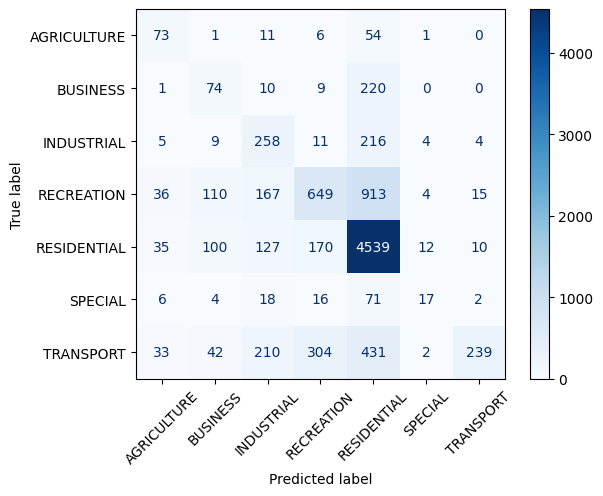

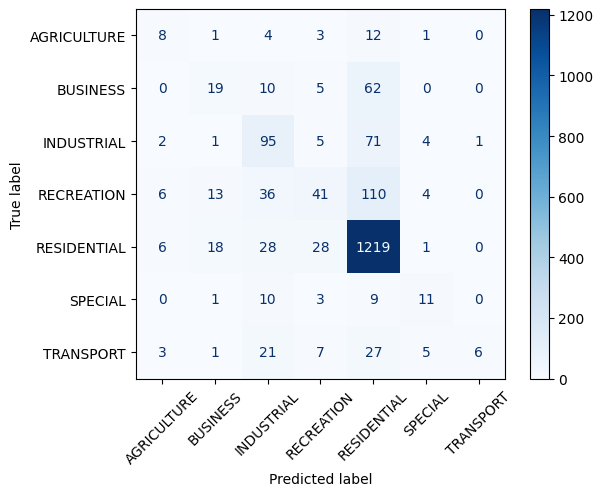

In [143]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\nОтчёт по тестовой выборке Санкт-Петербурга:")
print(classification_report(y_test_spb, y_pred_spb, target_names=le.classes_))


cm = confusion_matrix(y_test_spb, y_pred_spb, labels=range(len(le.classes_)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)

print("\nОтчёт по тестовой выборке Кемерово:")
print(classification_report(y_test_kem, y_pred_kem, target_names=le.classes_))


cm = confusion_matrix(y_test_kem, y_pred_kem, labels=range(len(le.classes_)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)


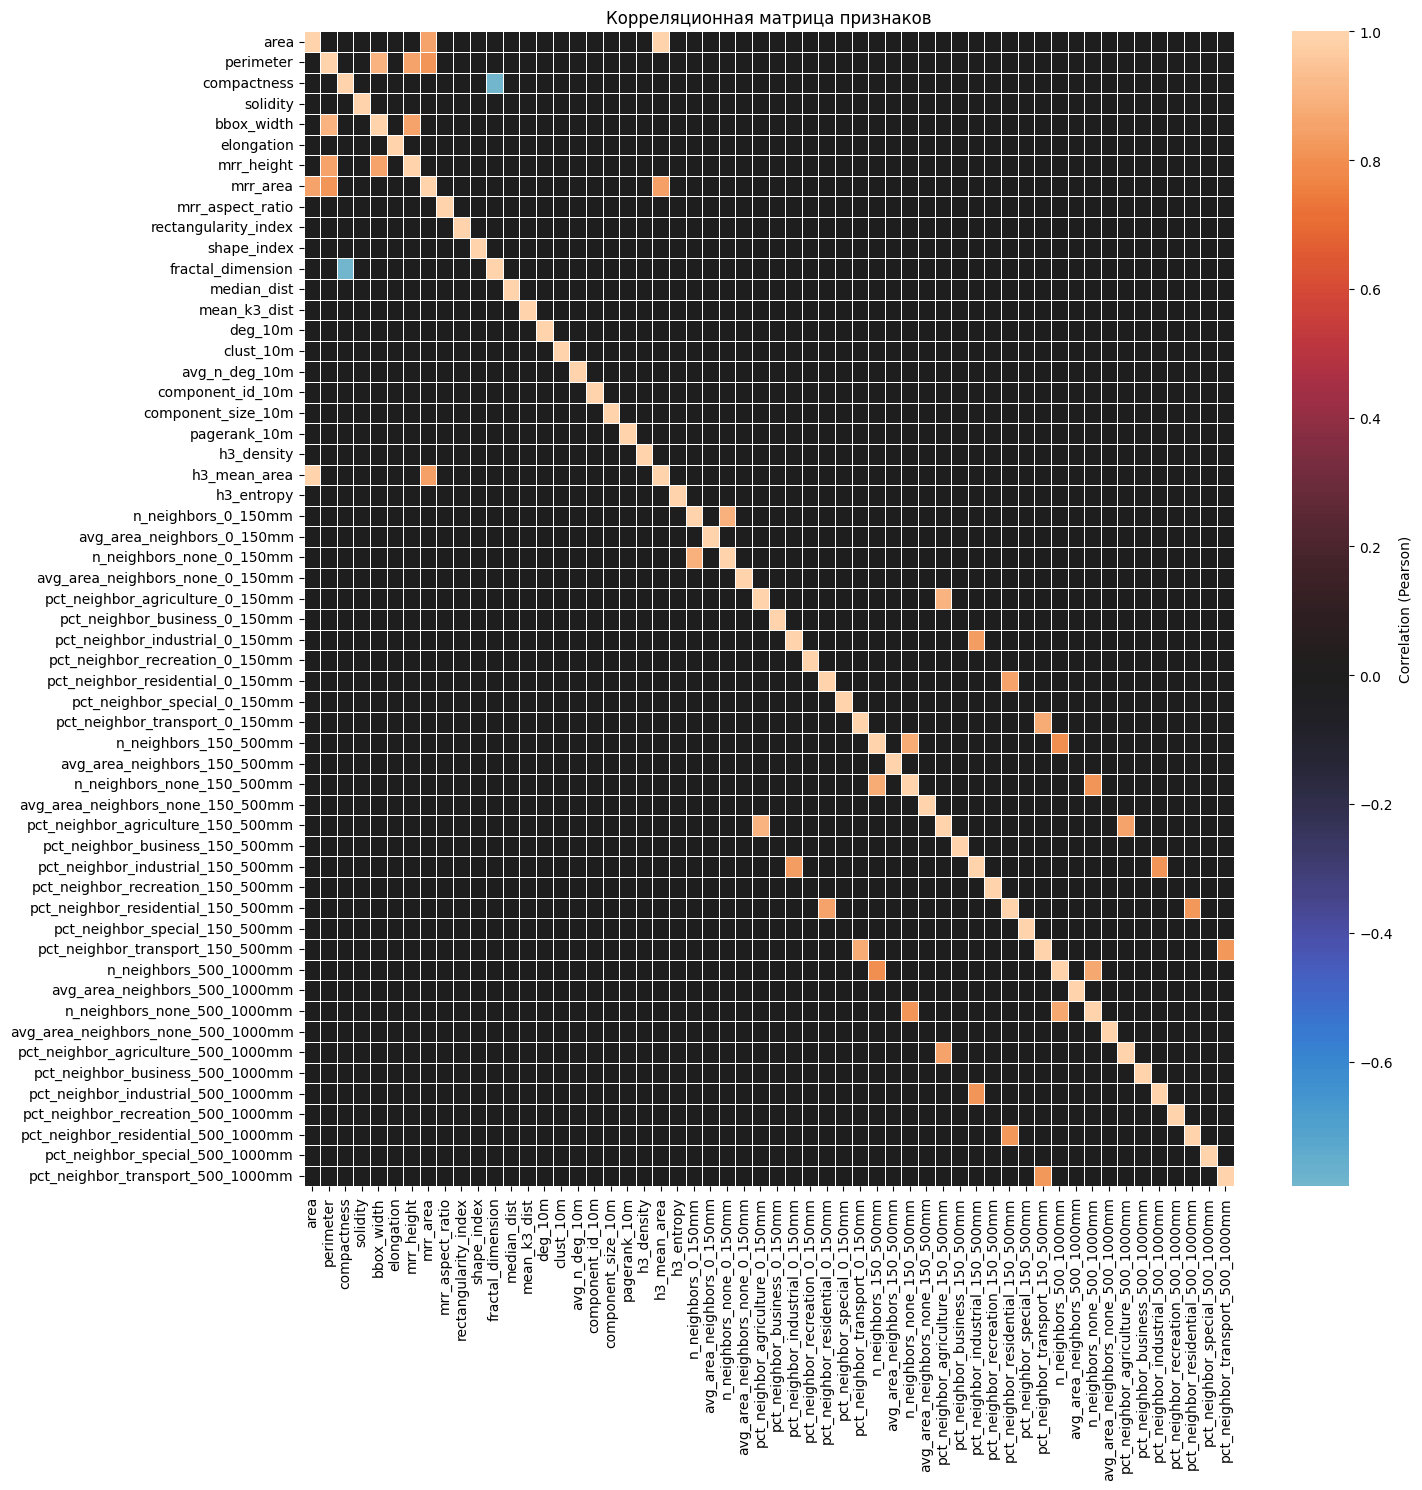

In [130]:
# корреляционная матрица
corr = pd.DataFrame(X_train, columns=feature_cols).corr(method='pearson')

# визуализация
plt.figure(figsize=(15, 15))
sns.heatmap(
    corr[(corr > 0.8) | (corr < -0.6)].fillna(0),
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation (Pearson)'},
)
plt.title("Корреляционная матрица признаков")
plt.show()

In [131]:
XGB_fi = voting.named_estimators_['XGB'].feature_importances_ / max(voting.named_estimators_['XGB'].feature_importances_)
LGBM_fi = voting.named_estimators_['LGBM'].feature_importances_ / max(voting.named_estimators_['LGBM'].feature_importances_)
RF_fi = voting.named_estimators_['RF'].feature_importances_ / max(voting.named_estimators_['RF'].feature_importances_)
CB_fi = voting.named_estimators_['CB'].feature_importances_ / max(voting.named_estimators_['CB'].feature_importances_)

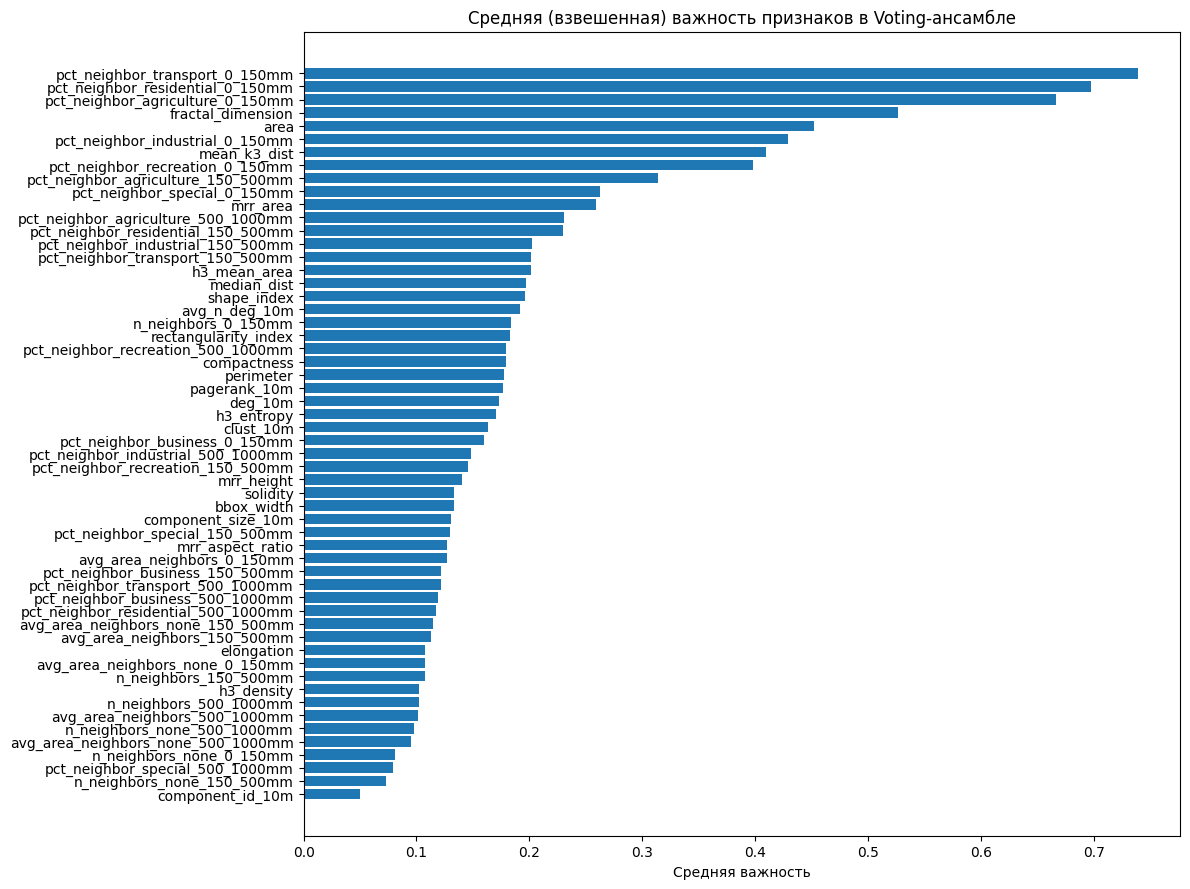

,XGB_importance,LGBM_importance,RF_importance,CB_importance,Weighted_mean
feature,,,,,
pct_neighbor_transport_0_150mm,1.000000,0.318856,1.000000,0.639419,0.739569
pct_neighbor_residential_0_150mm,0.724214,0.456568,0.611062,1.000000,0.697961
pct_neighbor_agriculture_0_150mm,0.966660,0.265890,0.795718,0.639179,0.666862
fractal_dimension,0.074540,1.000000,0.507865,0.525251,0.526914
area,0.103421,0.713983,0.460241,0.530676,0.452080
pct_neighbor_industrial_0_150mm,0.445930,0.336864,0.630844,0.303074,0.429178
mean_k3_dist,0.061207,0.909958,0.380134,0.289252,0.410138
pct_neighbor_recreation_0_150mm,0.360728,0.343220,0.462976,0.424420,0.397836
pct_neighbor_agriculture_150_500mm,0.064731,0.251059,0.750038,0.191473,0.314325


In [132]:
df_importances = pd.DataFrame({
    'feature': feature_cols,
    'XGB_importance': XGB_fi,
    'LGBM_importance': LGBM_fi,
    'RF_importance': RF_fi,
    'CB_importance': CB_fi
})

df_importances.set_index('feature', inplace=True)
df_importances = df_importances.sort_values(by='XGB_importance', ascending=False)

df_importances['Weighted_mean'] = (
    df_importances['XGB_importance'] +
    df_importances['LGBM_importance'] +
    df_importances['RF_importance'] + 
    df_importances['CB_importance']
) / (4)

df_importances.sort_values(by='Weighted_mean', ascending=False, inplace=True)

plt.figure(figsize=(12, 9))
plt.barh(df_importances.index, df_importances['Weighted_mean'])
plt.gca().invert_yaxis()
plt.title("Средняя (взвешенная) важность признаков в Voting-ансамбле")
plt.xlabel("Средняя важность")
plt.tight_layout()
plt.show()

df_importances


In [ ]:
m = test_gdf_kem[['geometry', 'target', 'predict']].explore('predict', tiles='Carto DB Positron')
test_gdf_kem[['geometry', 'target', 'predict']].explore('target', m=m)

------------------------------------------------------------------------------------

In [70]:
# --- Иерархия меток ---
# L1: RESIDENTIAL vs OTHER
map7_to_L1 = {
    "RESIDENTIAL": "RESIDENTIAL",
    "BUSINESS": "OTHER",
    "SPECIAL": "OTHER",
    "TRANSPORT": "OTHER",
    "AGRICULTURE": "OTHER",
    "RECREATION": "OTHER",
    "INDUSTRIAL": "OTHER",
}

# L2: для OTHER → 4 укрупнённые класса
map7_to_L2 = {
    "BUSINESS": "BUSINESS",
    "SPECIAL": "SPECIAL",
    "TRANSPORT": "TRANSPORT",
    "AGRICULTURE": "LARGEAREA",
    "RECREATION": "LARGEAREA",
    "INDUSTRIAL": "LARGEAREA",
    "RESIDENTIAL": None,  # не используется на этом уровне
}

# L3: для LARGEAREA → 3 листа
map7_to_L3 = {
    "AGRICULTURE": "AGRICULTURE",
    "RECREATION": "RECREATION",
    "INDUSTRIAL": "INDUSTRIAL",
    "RESIDENTIAL": None,
    "BUSINESS": None,
    "SPECIAL": None,
    "TRANSPORT": None,
}

# Целевые листья финальной схемы
LEAF_CLASSES = ["RESIDENTIAL", "BUSINESS", "SPECIAL", "TRANSPORT",
                "AGRICULTURE", "RECREATION", "INDUSTRIAL"]

In [71]:
y7 = pd.Series(y_train_str).astype(str)

# L1
y_L1 = y7.map(map7_to_L1)
mask_L1 = y_L1.notna()
y_L1 = y_L1[mask_L1]
X_L1 = X_train_scaled[mask_L1.values]

# L2 (только OTHER)
mask_OTHER = (y_L1 == "OTHER")
y_L2 = y7[mask_L1].map(map7_to_L2)
X_L2 = X_L1[mask_OTHER.values]
y_L2 = y_L2[mask_OTHER.values]

# L3 (только LARGEAREA)
mask_LARGE = (y_L2 == "LARGEAREA")
y_L3 = y7[mask_L1][mask_OTHER].map(map7_to_L3)
X_L3 = X_L2[mask_LARGE.values]
y_L3 = y_L3[mask_LARGE.values]

from sklearn.preprocessing import LabelEncoder
le_L1 = LabelEncoder().fit(y_L1)                   # ['OTHER','RESIDENTIAL']
le_L2 = LabelEncoder().fit(y_L2)                   # ['BUSINESS','LARGEAREA','SPECIAL','TRANSPORT']
le_L3 = LabelEncoder().fit(y_L3)                   # ['AGRICULTURE','INDUSTRIAL','RECREATION']

In [72]:
clf_L1 = VotingClassifier(
    estimators=voting_models,
    voting='soft',
    weights=[1.8, 1.2, 1.5, 1], 
    n_jobs=-1
).fit(X_L1, le_L1.transform(y_L1))

clf_L2 = VotingClassifier(
    estimators=voting_models,
    voting='soft',
    weights=[1.8, 1.2, 1.5, 1], 
    n_jobs=-1
).fit(X_L2, le_L2.transform(y_L2))

clf_L3 = VotingClassifier(
    estimators=voting_models,
    voting='soft',
    weights=[1.8, 1.2, 1.5, 1], 
    n_jobs=-1
).fit(X_L3, le_L3.transform(y_L3))

In [90]:
import numpy as np

def hier_predict_labels(X):
    # L1
    p_L1 = clf_L1.predict(X)
    classes_L1 = le_L1.classes_
    idx_RES = np.where(classes_L1 == "RESIDENTIAL")[0][0]
    idx_OTH = np.where(classes_L1 == "OTHER")[0][0]
    is_RES = (p_L1 == idx_RES)

    # Prepare output
    y_pred = np.empty(len(X), dtype=object)
    y_pred[is_RES] = "RESIDENTIAL"

    # L2 for OTHER
    if (~is_RES).any():
        X_o = X[~is_RES]
        p_L2 = clf_L2.predict(X_o)
        classes_L2 = le_L2.classes_
        pred_L2 = classes_L2[p_L2]

        # If LARGEAREA → L3
        is_LA = (pred_L2 == "LARGEAREA")
        y_pred_o = pred_L2.copy()
        if is_LA.any():
            X_la = X_o[is_LA]
            p_L3 = clf_L3.predict(X_la)
            classes_L3 = le_L3.classes_
            pred_L3 = classes_L3[p_L3]
            y_pred_o[is_LA] = pred_L3

        # write back
        y_pred[~is_RES] = y_pred_o

    return y_pred

In [74]:
def hier_predict_proba(X):
    # Приведём к единому вектору вероятностей по LEAF_CLASSES
    proba = np.zeros((len(X), len(LEAF_CLASSES)), dtype=float)

    # L1
    p_L1 = clf_L1.predict_proba(X)
    classes_L1 = le_L1.classes_
    p_RES = p_L1[:, np.where(classes_L1 == "RESIDENTIAL")[0][0]]
    p_OTH = p_L1[:, np.where(classes_L1 == "OTHER")[0][0]]

    # P(RESIDENTIAL)
    proba[:, LEAF_CLASSES.index("RESIDENTIAL")] = p_RES

    # L2 (можно считать на всех X, веса задаст p_OTH)
    p_L2 = clf_L2.predict_proba(X)
    classes_L2 = le_L2.classes_
    # P(BUSINESS/SPECIAL/TRANSPORT) = p_OTH * p_L2[class]
    for c in ["BUSINESS", "SPECIAL", "TRANSPORT"]:
        proba[:, LEAF_CLASSES.index(c)] = p_OTH * p_L2[:, np.where(classes_L2 == c)[0][0]]

    # P(LARGEAREA)
    p_LA = p_OTH * p_L2[:, np.where(classes_L2 == "LARGEAREA")[0][0]]

    # L3 (на всех X, веса задаст p_LA)
    p_L3 = clf_L3.predict_proba(X)
    classes_L3 = le_L3.classes_
    for c in ["AGRICULTURE", "RECREATION", "INDUSTRIAL"]:
        proba[:, LEAF_CLASSES.index(c)] = p_LA * p_L3[:, np.where(classes_L3 == c)[0][0]]

    # нормализация (на случай численных артефактов)
    s = proba.sum(axis=1, keepdims=True)
    s[s == 0] = 1.0
    proba /= s
    return proba

def hier_predict_labels_prob(X):
    proba = hier_predict_proba(X)
    return np.array(LEAF_CLASSES)[proba.argmax(axis=1)]


In [85]:
def fom_report(y_true, y_pred, labels=None, target_names=None):
    """
    Возвращает DataFrame как classification_report, дополнив колонкой 'fom' (IoU/Jaccard).
    Работает для мультикласса и бинарной классификации.
    """
    # Базовый отчёт
    rep = classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )
    df = pd.DataFrame(rep).T

    # Перекодируем пер-класс FoM (average=None -> вектор по классам)
    # Важно: передать тот же порядок labels, чтобы совпало с target_names/индексами отчёта
    per_class_fom = jaccard_score(
        y_true, y_pred,
        labels=labels,
        average=None
    )

    # Сопоставляем индексам отчёта
    if target_names is not None and labels is not None:
        class_rows = target_names
    elif labels is not None:
        class_rows = [str(l) for l in labels]
    else:
        # sklearn сам определил порядок меток; берём те, что выглядят как классы
        class_rows = [idx for idx in df.index if idx not in ('accuracy','macro avg','weighted avg')]

    # Добавляем per-class FoM
    for i, row in enumerate(class_rows):
        df.loc[row, 'fom'] = per_class_fom[i] if i < len(per_class_fom) else np.nan

    # Добавляем агрегаты FoM
    for avg_name in ('micro', 'macro', 'weighted'):
        try:
            df.loc[f'{avg_name} avg', 'fom'] = jaccard_score(
                y_true, y_pred, labels=labels, average=avg_name
            )
        except Exception:
            df.loc[f'{avg_name} avg', 'fom'] = np.nan

    # Заполним NaN нулями для стабильности вывода
    return df.fillna(0.0)


In [91]:
from sklearn.metrics import classification_report, cohen_kappa_score, jaccard_score

y_true_spb = spb_test['target'].astype(str).values
y_true_kem = kem_test['target'].astype(str).values

# Вариант 1: жадный
y_pred_spb = hier_predict_labels(X_test_spb)
y_pred_kem = hier_predict_labels(X_test_kem)

print("SPB:")
print(classification_report(y_true_spb, y_pred_spb, labels=LEAF_CLASSES, zero_division=0))
print("KEM:")
print(classification_report(y_true_kem, y_pred_kem, labels=LEAF_CLASSES, zero_division=0))

print("SPB κ:", cohen_kappa_score(y_true_spb, y_pred_spb))
print("KEM κ:", cohen_kappa_score(y_true_kem, y_pred_kem))

print("\nSPB:")
report = fom_report(y_true_spb, y_pred_spb, labels=LEAF_CLASSES)
print(report.to_string(float_format=lambda x: f"{x:.3f}"))

print("\nKEM:")
report = fom_report(y_true_kem, y_pred_kem, labels=LEAF_CLASSES)
print(report.to_string(float_format=lambda x: f"{x:.3f}"))

SPB:
              precision    recall  f1-score   support

 RESIDENTIAL       0.75      0.89      0.82      4993
    BUSINESS       0.23      0.21      0.22       314
     SPECIAL       0.45      0.13      0.20       134
   TRANSPORT       0.88      0.22      0.35      1261
 AGRICULTURE       0.41      0.49      0.45       146
  RECREATION       0.58      0.45      0.51      1894
  INDUSTRIAL       0.27      0.55      0.36       507

    accuracy                           0.65      9249
   macro avg       0.51      0.42      0.41      9249
weighted avg       0.68      0.65      0.63      9249

KEM:
              precision    recall  f1-score   support

 RESIDENTIAL       0.81      0.93      0.86      1300
    BUSINESS       0.39      0.20      0.26        96
     SPECIAL       0.43      0.29      0.35        34
   TRANSPORT       0.89      0.11      0.20        70
 AGRICULTURE       0.30      0.28      0.29        29
  RECREATION       0.42      0.20      0.27       210
  INDUSTRIAL  

In [112]:
pred_L1 = clf_L1.predict(X_test_spb)
print(classification_report(le_L1.transform(spb_test['target'].map(map7_to_L1)), pred_L1, target_names=le_L1.classes_, zero_division=0))
print(jaccard_score(le_L1.transform(spb_test['target'].map(map7_to_L1)), pred_L1))

              precision    recall  f1-score   support

       OTHER       0.83      0.66      0.74      4256
 RESIDENTIAL       0.75      0.89      0.82      4993

    accuracy                           0.78      9249
   macro avg       0.79      0.77      0.78      9249
weighted avg       0.79      0.78      0.78      9249

0.6887026691495965
